<a href="https://colab.research.google.com/github/Mahmoud-Azmy/Academic-master/blob/academic_master_v2/frist_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 11.jpg to 11 (6).jpg
Original Image:


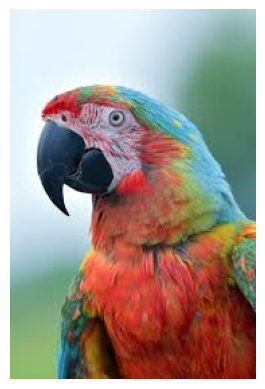

In [17]:
# -----------------------------------------------------
# 1. Upload Image
# -----------------------------------------------------
from google.colab import files
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
import numpy as np
import cv2

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load original image
img = Image.open(filename)
print("Original Image:")
plt.imshow(img)
plt.axis('off')
plt.show()

# -----------------------------------------------------
# 2. Convert to GRAYSCALE
# -----------------------------------------------------
gray = img.convert("L")
gray_np = np.array(gray)

cl_np=np.array(img)

print("Grayscale:")
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

# -----------------------------------------------------
# 3. Grayscale → RGB (plain color)
# -----------------------------------------------------
rgb_from_gray = np.stack([gray_np, gray_np, gray_np], axis=-1)

print("Grayscale → RGB:")
plt.imshow(rgb_from_gray)
plt.axis('off')
plt.show()

# -----------------------------------------------------
# 4. Color Map (PSEUDO-COLOR)
# -----------------------------------------------------
# Choose colormap: JET, HOT, OCEAN, RAINBOW, BONE...
color_map_image = cv2.applyColorMap(gray_np, cv2.COLORMAP_SUMMER)

print("Color Map (JET):")
plt.imshow(cv2.cvtColor(color_map_image, cv2.COLOR_BGR2RGB))  # Convert BGR→RGB for plotting
plt.axis('off')
plt.show()

# -----------------------------------------------------
# 5. Binary Image (Thresholding)
# -----------------------------------------------------
_, binary = cv2.threshold(gray_np, 128, 255, cv2.THRESH_BINARY)

print("Binary:")
plt.imshow(binary, cmap='grey')
plt.axis('off')
plt.show()

# -----------------------------------------------------
# 6. Resize Image
# -----------------------------------------------------
resized = img.resize((300, 300))
print("Resized (300×300):")
plt.imshow(resized)
plt.axis('off')
plt.show()

# -----------------------------------------------------
# 7. Histogram
# -----------------------------------------------------
print("Histogram:")
plt.hist(cl_np.flatten(), bins=256, color='black')
plt.title("Grayscale Histogram")
plt.show()

# -----------------------------------------------------
# 8. Filters
# -----------------------------------------------------
blur = img.filter(ImageFilter.BLUR)
sharpen = img.filter(ImageFilter.SHARPEN)
edges = img.filter(ImageFilter.FIND_EDGES)

print("Blur / Sharpen / Edges:")
fig, axs = plt.subplots(1, 3, figsize=(12,4))

axs[0].imshow(blur)
axs[0].set_title("Blur")
axs[0].axis('off')

axs[1].imshow(sharpen)
axs[1].set_title("Sharpen")
axs[1].axis('off')

axs[2].imshow(edges)
axs[2].set_title("Edges")
axs[2].axis('off')

plt.show()

# -----------------------------------------------------
# 9. Extract RGB Channels
# -----------------------------------------------------
r, g, b = img.split()

print("RGB Channels:")
fig, axs = plt.subplots(1, 3, figsize=(12,4))

axs[0].imshow(r, cmap='Reds')
axs[0].set_title("Red Channel")
axs[0].axis('off')

axs[1].imshow(g, cmap='Greens')
axs[1].set_title("Green Channel")
axs[1].axis('off')

axs[2].imshow(b, cmap='Blues')
axs[2].set_title("Blue Channel")
axs[2].axis('off')

plt.show()

# -----------------------------------------------------
# 10. Save output files
# -----------------------------------------------------
gray.save("gray_image.jpg")
resized.save("resized_image.jpg")
Image.fromarray(binary).save("binary_image.jpg")
blur.save("blur_image.jpg")
sharpen.save("sharpen_image.jpg")
edges.save("edges_image.jpg")
Image.fromarray(rgb_from_gray).save("rgb_from_gray.jpg")
cv2.imwrite("colormap_image.jpg", color_map_image)

print("\nSaved files:")
print(" - gray_image.jpg")
print(" - resized_image.jpg")
print(" - binary_image.jpg")
print(" - blur_image.jpg")
print(" - sharpen_image.jpg")
print(" - edges_image.jpg")
print(" - rgb_from_gray.jpg")
print(" - colormap_image.jpg")

# -----------------------------------------------------
# 11. Read first 200 bytes
# -----------------------------------------------------
with open(filename, "rb") as f:
    bytes_data = f.read()

print("\nFirst 200 bytes of the image:")
print(bytes_data[:200])